In [1]:
import time
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from concrete.ml.sklearn import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot as plt
from sklearn import metrics
from sklearn.metrics import classification_report

# Evaluation Baseline - Classification Models

### Make classification samples and perform train and test split

Min
- Tells us how small the smallest value is across all features and samples.
- Useful to check if your features contain negative values which are important for certain models sensitive to input ranges as well as quantization which may work better with normalized or strictly postive ranges

Max
- Shows how large the largest value is across all features and samples
- Helps assess whether outliers exist and if scaling/normalization may help improve model performance or stability

In [2]:
x, y = make_classification(n_samples=100, class_sep=2, n_features=30, random_state=42)

print("X Minimum: ", x.min())
print("X Maximum: ", x.max())

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

X Minimum:  -3.8192253511146537
X Maximum:  3.625093656245981


### Evaluate number of training and testing samples from train/test split

Number of Samples
- Ensures you have enough data to train and evaluate the model effectively
- Confirms train/test split proportions are appropriate for fair performance assessment

Shape of Data
- Verifies the feature dimensions match the model's input expectations
- Helps detect structural issues like missing values, reshaping errors or misaligned label arrays

In [3]:
num_x_training = len(x_train)
num_x_test = len(x_test)
num_y_training = len(y_train)
num_y_test = len(y_test)

print("Number of x training: ", num_x_training)
print("Number of x test: ", num_x_test)
print("Number of y training: ", num_y_training)
print("Number of y test: ", num_y_test)

Number of x training:  90
Number of x test:  10
Number of y training:  90
Number of y test:  10


In [4]:
print("x_train shape: ", x_train.shape)
print("x_test shape: ", x_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_train.shape) 

x_train shape:  (90, 30)
x_test shape:  (10, 30)
y_train shape:  (90,)
y_test shape:  (90,)


### Initialise Model and Perform Fitting and Prediction

In [5]:
total_start_time = time.time()

model = LogisticRegression(n_bits=8)

ml_start_time = time.time()

model.fit(x_train, y_train)
y_pred_clear = model.predict(x_test)
model.compile(x_train)

ml_end_time = time.time()

[cctools-port]: generating fake signature for '/var/folders/np/csvtz3fn3w5gwpvph62t5y180000gn/T/tmpdslojn10/sharedlib.dylib'


### Evaluate accuracy performed on the cleartext during prediction

Performance Metrics on Cleartext
- Accuracy measures the overall correctness which is useful for balanced datasets.
- Precision tells us how many predicted positives were actually correct and is important when false positives are costly.
- Recall captures how many actual positives were correctly identified and are critical when false negatives matter
- F1 Score balances precision and recall and is especially valuable for imbalanced classes
- AUC (ROC) evaluates how well the model separates classes across thresholds and is a robust measure of classification performance
- Elapsed Time (ML Prediction Time) reflects how fast the model can predict in cleartext. Useful for comparing with FHE execution time to assess performance trade-offs

In [6]:
clear_accuracy = accuracy_score(y_test, y_pred_clear)
clear_precision = precision_score(y_test, y_pred_clear)
clear_recall = recall_score (y_test, y_pred_clear)
clear_f1 = f1_score(y_test, y_pred_clear)
clear_auc = roc_auc_score(y_test, y_pred_clear)
ml_elapsed_time = ml_end_time - ml_start_time

print("Cleartext Accuracy Score: ", clear_accuracy)
print("Cleartext Precision Score: ", clear_precision)
print("Cleartext Recall Score: ", clear_recall)
print("Cleartext F1 Score: ", clear_f1)
print("Cleartext AUC Score: ", clear_auc)
print(f"Time it took for ML to make predictions: {ml_elapsed_time:.5f} seconds")

Cleartext Accuracy Score:  1.0
Cleartext Precision Score:  1.0
Cleartext Recall Score:  1.0
Cleartext F1 Score:  1.0
Cleartext AUC Score:  1.0
Time it took for ML to make predictions: 0.19286 seconds


### Confusion Matrix - Cleartext

- Provides a visual breakdown of prediction results. Shows counts of true positives, false positives, true negatives, and false negatives and helps understand what kind of errors the model is making.
- Provides class-specific performance insight. Reveals which class is being misclassified and how often which would support better debugging or retraining decisions.

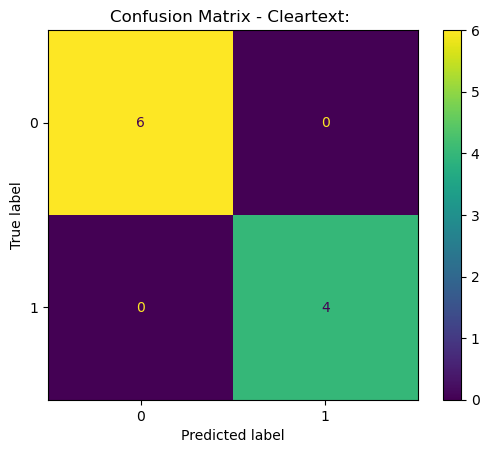

In [7]:
cm = metrics.confusion_matrix(y_test, y_pred_clear)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Cleartext: ")
plt.show()

### Classification Report - Cleartext

- Provides precision, recall, F1-score, and support for each class. Offers a comprehensive look at how the model performs on each label.
- Helps assess if the model is biased toward one class by comparing metric values across classes.

In [8]:
print("Classification Report - Cleartext: ")
print(classification_report(y_test, y_pred_clear))

Classification Report - Cleartext: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



### FHE Execution and Evaluation

In [9]:
fhe_prediction_start_time = time.time()

y_pred_fhe = model.predict(x_test, fhe="execute")

fhe_prediction_end_time = time.time()

### Evaluate accuracy performed during FHE prediction

Performance Metrics on FHE
- Accuracy measures the overall correctness which is useful for balanced datasets.
- Precision tells us how many predicted positives were actually correct and is important when false positives are costly.
- Recall captures how many actual positives were correctly identified and are critical when false negatives matter
- F1 Score balances precision and recall and is especially valuable for imbalanced classes
- AUC (ROC) evaluates how well the model separates classes across thresholds and is a robust measure of classification performance
- Elapsed Time (ML Prediction Time) reflects how fast the model can predict in cleartext. Useful for comparing with FHE execution time to assess performance trade-offs

In [10]:
fhe_accuracy = accuracy_score(y_test, y_pred_fhe)
fhe_precision = precision_score(y_test, y_pred_fhe)
fhe_recall = recall_score (y_test, y_pred_fhe)
fhe_f1 = f1_score(y_test, y_pred_fhe)
fhe_auc = roc_auc_score(y_test, y_pred_fhe)
fhe_prediction_elapsed_time = fhe_prediction_end_time - fhe_prediction_start_time

print("FHE Accuracy Score: ", fhe_accuracy)
print("FHE Precision Score: ", fhe_precision)
print("FHE Recall Score: ", fhe_recall)
print("FHE F1 Score: ", fhe_f1)
print("FHE AUC Score: ", fhe_auc)
print(f"Total time for FHE Execution and Evaluation: {fhe_prediction_elapsed_time:.5f} seconds")

FHE Accuracy Score:  1.0
FHE Precision Score:  1.0
FHE Recall Score:  1.0
FHE F1 Score:  1.0
FHE AUC Score:  1.0
Total time for FHE Execution and Evaluation: 0.65773 seconds


### Confusion Matrix - FHE

- Provides a visual breakdown of prediction results. Shows counts of true positives, false positives, true negatives, and false negatives and helps understand what kind of errors the model is making.
- Provides class-specific performance insight. Reveals which class is being misclassified and how often which would support better debugging or retraining decisions.

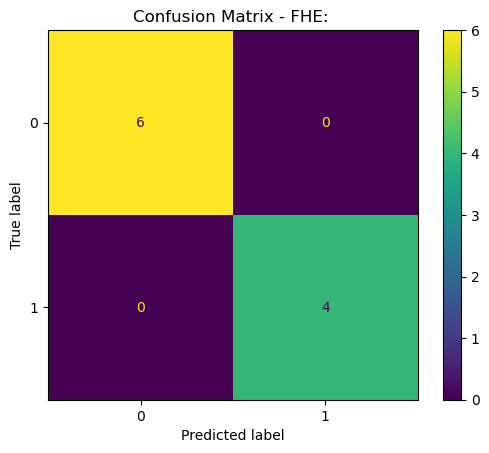

In [11]:
cm = metrics.confusion_matrix(y_test, y_pred_fhe)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - FHE: ")
plt.show()

### Classification Report - FHE

- Provides precision, recall, F1-score, and support for each class. Offers a comprehensive look at how the model performs on each label.
- Helps assess if the model is biased toward one class by comparing metric values across classes.

In [12]:
print("Classification Report - FHE: ")
print(classification_report(y_test, y_pred_fhe))

Classification Report - FHE: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



### Evaluation of Model
- Shows predictions made by the model running on the plaintext (clear)
- Shows predictions made by the model running on the encrypted text
- Similarity shows how often the FHE predictions match the plaintext one
- Shows total runtime of the process of training/test/FHE

In [13]:
print("In clear  :", y_pred_clear)
print("In FHE    :", y_pred_fhe)
print(f"Similarity: {int((y_pred_fhe == y_pred_clear).mean()*100)}%")

total_end_time = time.time()
total_elapsed_time = total_end_time - total_start_time
print(f"Total time for model to Run: {total_elapsed_time:.5f} seconds")

In clear  : [0 0 0 0 1 0 1 0 1 1]
In FHE    : [0 0 0 0 1 0 1 0 1 1]
Similarity: 100%
Total time for model to Run: 1.10863 seconds


### Evaluation of all results (from each model)

In [14]:
results = {'100 Dataset':["100", 
     f"{(y_pred_fhe == y_pred_clear).mean() * 100:.0f}%", 
     ml_elapsed_time,
     clear_accuracy,
     clear_precision,
     clear_recall,
     clear_f1,
     clear_auc,
     fhe_prediction_elapsed_time,
     fhe_accuracy,
     fhe_precision,
     fhe_recall,
     fhe_f1,
     fhe_auc, 
     total_elapsed_time]
}

headers = ['Samples', 'Similarity', 'ML Time','CT Accuracy', 'CT Precision', 'CT Recall', 'CT F1', 
           'CT AUC', 'FHE Time', 'FHE Accuracy', 'FHE Precision', 'FHE Recall', 'FHE F1', 'FHE AUC', 'Total Time']

overall_results = pd.DataFrame(results, index=headers).T.round(2)
overall_results


,Samples,Similarity,ML Time,CT Accuracy,CT Precision,CT Recall,CT F1,CT AUC,FHE Time,FHE Accuracy,FHE Precision,FHE Recall,FHE F1,FHE AUC,Total Time
100 Dataset,100,100%,0.192857,1.0,1.0,1.0,1.0,1.0,0.65773,1.0,1.0,1.0,1.0,1.0,1.10863
